# Train segmentation model

## Training the segmentation head from embeddings

In this notebook you can train the segmentation model using pre-computed embeddings via LightningCLI using configurations in `configs/train_embedding_classifier.yaml`. Modify the batch size, learning rate, and other hyperparameters in the configuration file as needed.

This notebook uses a CSV logger by default for training, validation and test results. A [WandB logger](https://lightning.ai/docs/pytorch/stable/extensions/generated/lightning.pytorch.loggers.WandbLogger.html#lightning.pytorch.loggers.WandbLogger) can also be used. If you prefer the latter, please switch the loggers and update the entity of the WandB logger configuration in `configs/train_embedding_classifier.yaml`.


In [1]:
import os
from pathlib import Path

def find_project_root(marker='claymodel'):
    current = Path.cwd()
    for path in [current] + list(current.parents):
        if (path / marker).exists():
            return path
    raise FileNotFoundError(f"Project root not found")

os.chdir(find_project_root())


In [2]:
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.cli import LightningArgumentParser, instantiate_class
import lightning.pytorch as L

# from claymodel.finetune.flood_detection.embedding_gfm_classifier import EmbeddingClassifierGFM
from claymodel.finetune.flood_detection.embedding_gfm_classifier_v3 import EmbeddingClassifierGFM
from claymodel.finetune.flood_detection.embedding_datamodule_gfm_3 import EmbeddingDataModuleGFM3

from datetime import datetime

seed_everything(42)  # your seed here

def Train_segmentation_from_embeddings(config_path, test_after_training=False):
    
    objects = ["callbacks", "logger", "plugins"]

    # Create argument parser similar to LightningCLI
    parser = LightningArgumentParser()
    parser.add_lightning_class_args(EmbeddingClassifierGFM, "model")
    parser.add_lightning_class_args(EmbeddingDataModuleGFM3, "data")
    parser.add_lightning_class_args(Trainer, "trainer")
    
    # Parse the config file
    config = parser.parse_path(config_path)

    trainer_config = dict(config["trainer"])
    
    # Instantiate objects
    for object in objects:
        if object in trainer_config and trainer_config[object]:
            callbacks = []
            for callback_config in trainer_config[object]:
                if hasattr(callback_config, 'class_path') and hasattr(callback_config, 'init_args'):
                    
                    if object == "logger":
                        if callback_config.class_path == "lightning.pytorch.loggers.CSVLogger":
                            callback_config.init_args['version'] = datetime.now().strftime("%Y%m%d_%H%M%S")
                        elif callback_config.class_path == "lightning.pytorch.loggers.WandbLogger":
                            callback_config.init_args['name'] = "GFM_model_v4" + datetime.now().strftime("%Y%m%d_%H%M%S")

                    if object == "callbacks" and callback_config.class_path == "lightning.pytorch.callbacks.ModelCheckpoint":
                        callback_config.init_args['dirpath'] = os.path.join(callback_config.init_args['dirpath'], datetime.now().strftime("%Y%m%d_%H%M%S"))
                    callback = instantiate_class((), callback_config)
                    callbacks.append(callback)        

                elif isinstance(callback_config, dict) and "class_path" in callback_config:
                    # This is a dictionary configuration
                    callback = instantiate_class((), callback_config)
                    callbacks.append(callback)
                else:
                    # Already an instantiated callback
                    callbacks.append(callback_config)
            
            trainer_config[object] = callbacks

    # Create instances
    model = EmbeddingClassifierGFM(**config["model"])
    datamodule = EmbeddingDataModuleGFM3(**config["data"])
    trainer = Trainer(**trainer_config)

        # Log the full model config to Weights & Biases, if enabled
    try:
        model_config = dict(config["model"])  # ensure standard dict
        for logger in trainer.loggers:
            if isinstance(logger, L.pytorch.loggers.WandbLogger):
                run = logger.experiment  # wandb.Run
                if run is not None:
                    run.config.update({"model": model_config}, allow_val_change=True)
            elif isinstance(logger, L.pytorch.loggers.CSVLogger):
                # Store under 'model' key in hparams.yaml within the CSV log dir
                logger.log_hyperparams({"model": model_config})
    except Exception:
        # Be robust if loggers differ or dependencies are missing
        pass

    result = trainer.fit(model, datamodule)
    if test_after_training:
        result = trainer.test(model, datamodule)
        print(model.confusion_matrix)

    print("Results:", result)
    
    return model, datamodule, trainer, result


/opt/conda/lib/python3.13/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Seed set to 42


## Training the model

Run the training process. The model will be trained using the configuration specified in `configs/train_embedding_classifier.yaml`. Set `test_after_training=True` to also run evaluation on the test set after training.


In [3]:
CONFIG_PATH = "configs/train_embedding_flood_detection.yaml"
model, *_ = Train_segmentation_from_embeddings(CONFIG_PATH, True)
#model.draw_graph().visual_graph

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTXA6000-12Q') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


🏗️  EmbeddingClassifierGFM initialized:
   Input: 1024D embeddings, 8x8 patches
   Output: Binary segmentation, (224, 224) spatial
   Fusion: early_concat
   SAR Fusion: True (mode: concat)
   ASPP: False, Residual: True


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: ignaciomasari (ignaciomasari-eodc) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/conda/lib/python3.13/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name              | Type                           | Params | Mode 
-----------------------------------------------------------------------------
0 | model             | TemporalFusionSegmentationHead | 21.2 M | train
1 | OA                | BinaryAccuracy                 | 0      | train
2 | loss_fn           | FocalLoss                      | 0      | train
3 | iou               | BinaryJaccardIndex             | 0      | train
4 | f1                | BinaryF1Score                  | 0      | train
5 | _confusion_matrix | BinaryConfusionMatrix          | 0      | train
-----------------------------------------------------------------------------
21.2 M    Trainable params
0         Non-trainable params
21

Training: |          | 0/? [00:00<?, ?it/s]

...

Epoch 27, global step 196: 'val/f1' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 28, global step 203: 'val/f1' was not in top 1
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/conda/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        Test metric               DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test/f1_epoch           0.6977868676185608
      test/iou_epoch           0.5969952344894409
      test/loss_epoch         0.019895503297448158
test/overall_accuracy_epoch    0.9483617544174194
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
{'val': tensor([[708145,  25676],
        [  5371, 114316]], device='cuda:0'), 'test': tensor([[1822038,   45571],
        [  66771,  255804]], device='cuda:0')}
Results: [{'test/loss_epoch': 0.019895503297448158, 'test/iou_epoch': 0.5969952344894409, 'test/f1_epoch': 0.6977868676185608, 'test/overall_accuracy_epoch': 0.9483617544174194}]


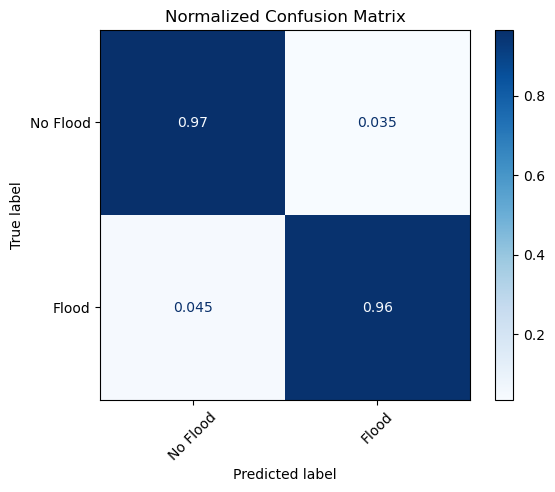

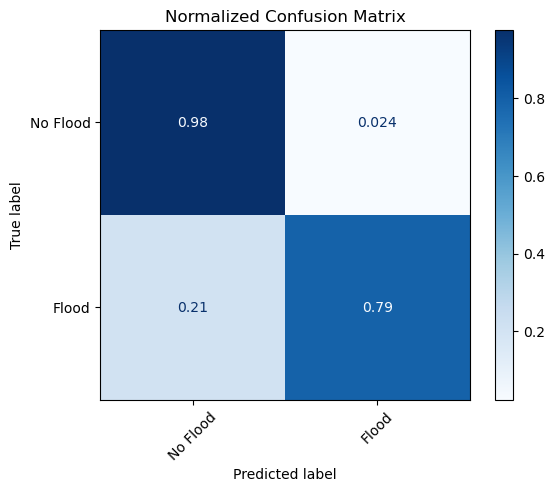

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

for phase in ["val", "test"]:
    cm_normalized = model.confusion_matrix[phase].cpu().numpy()
    cm_normalized = cm_normalized.astype('float') / cm_normalized.sum(axis=1)[:, np.newaxis]

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['No Flood', 'Flood'])
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title('Normalized Confusion Matrix')
    plt.show()

In [11]:
import random
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import rasterio as rio


def plot_random_n_chips(model, config_path_yaml, n: int = 5, split: str = "test"):
    """
    Visualize random chips for the GFM setup using paired pre/post embeddings and binary flood labels.

    Shows: pre SIG0, post SIG0, true flood mask, predicted flood mask, and ignore mask.
    """
    with open(config_path_yaml, "r") as f:
        config_dict = yaml.safe_load(f)

    if split == "train":
        embedding_path = Path(config_dict["data"]["train_embedd_dir"])  # .../chips/embeddings_checkpoints_clay-v1/
        labels_path = Path(config_dict["data"]["train_label_dir"])     # .../labels/
    elif split == "val":
        embedding_path = Path(config_dict["data"]["val_embedd_dir"])
        labels_path = Path(config_dict["data"]["val_label_dir"]) 
    elif split == "test":
        embedding_path = Path(config_dict["data"]["test_embedd_dir"])
        labels_path = Path(config_dict["data"]["test_label_dir"]) 
    else:
        raise ValueError("split must be 'train', 'val' or 'test'")

    # Chips are one level above embeddings_checkpoints_clay-v1
    # e.g., .../chips/embeddings_checkpoints_clay-v1 -> .../chips
    chips_path = embedding_path.parent

    # Pair pre/post embeddings by chip index (same logic as EmbeddingDatasetGFM)
    all_embed_files = [p.name for p in embedding_path.glob("*.npy")]
    key_to_files = {}
    for fname in all_embed_files:
        key = fname.split("chip", 1)[1] if "chip" in fname else Path(fname).stem
        key_to_files.setdefault(key, []).append(fname)
    paired_items = [(k, sorted(v)) for k, v in key_to_files.items() if len(v) == 2]
    paired_items.sort(key=lambda x: x[0])

    if len(paired_items) == 0:
        raise RuntimeError(f"No paired embeddings found in {embedding_path}")

    if n > len(paired_items):
        raise ValueError(
            f"n ({n}) is greater than the number of available pairs ({len(paired_items)})"
        )

    selected = random.sample(paired_items, n)

    # Prepare predictions
    model.eval()

    _, axs = plt.subplots(n, 5, figsize=(16, 4 * n))
    if n == 1:
        axs = np.expand_dims(axs, axis=0)

    for row_idx, (key, pair_files) in enumerate(selected):
        pre_name, post_name = pair_files[0], pair_files[1]
        pre_path = embedding_path / pre_name
        post_path = embedding_path / post_name

        # Derive chip index to find corresponding label and chip files
        token = pre_name.split("chip_", 1)[1]
        for char in token:
            if char.isnumeric(): 
                continue
            else:
                chip_idx = token.split(char, 1)[0]
                break

        # Load embeddings
        pre_embedding = np.load(pre_path).astype(np.float32)
        post_embedding = np.load(post_path).astype(np.float32)

        # Find and load labels/masks
        # FLOOD: 1 = flood, 0 = not flood
        # EXCLAYER: True to ignore
        # REFERENCE_WATER: 1 = permanent water (ignored)
        def find_first(pattern):
            matches = list((labels_path).glob(pattern))
            if len(matches) == 0:
                raise FileNotFoundError(f"No file matching {pattern} in {labels_path}")
            return matches[0]

        lbl_path = find_first(f"*FLOOD*chip_{chip_idx}*.npy")
        excl_path = find_first(f"*EXCLAYER*chip_{chip_idx}*.npy")
        water_path = find_first(f"*REFERENCE_WATER*chip_{chip_idx}*.npy")

        label = np.load(lbl_path).astype(np.uint8)
        excl = np.load(excl_path).astype(bool)
        water = (np.load(water_path) == 1)
        ignore_mask = (excl | water).astype(np.uint8)

        # Load corresponding raw chip images for visualization (pre/post)
        # Expect exactly 2 files per chip index in chips dir
        #chip_files = sorted(list((chips_path).glob(f"*chip_{chip_idx}*.npy")))
        #pre_img = None
        #post_img = None
        #if len(chip_files) >= 2:
        #    # Heuristic: first is pre, second is post after sort
        #    pre_img_np = np.load(chip_files[0]).astype(np.float32)
        #    post_img_np = np.load(chip_files[1]).astype(np.float32)
        #    # Display first band if multi-channel
        #    pre_img = pre_img_np[0] if pre_img_np.ndim == 3 else pre_img_np
        #    post_img = post_img_np[0] if post_img_np.ndim == 3 else post_img_np
        chip_files = sorted(list((chips_path).glob(f"*chip_{chip_idx}*.tif")))
        pre_img = None
        post_img = None
        if len(chip_files) >= 2:
            # Heuristic: first is pre, second is post after sort
            with rio.open(chip_files[0]) as src:
                pre_img_np = src.read().astype(np.float32)
            with rio.open(chip_files[1]) as src:
                post_img_np = src.read().astype(np.float32)
            
            # Display first band if multi-channel
            pre_img = pre_img_np[0] if pre_img_np.ndim == 3 else pre_img_np
            post_img = post_img_np[0] if post_img_np.ndim == 3 else post_img_np

        pre_img_batch = pre_img_np
        post_img_batch = pre_img_np
            
        # Predict
        with torch.no_grad():
            batch = {
                "pre_embedding": torch.from_numpy(pre_embedding).unsqueeze(0),
                "post_embedding": torch.from_numpy(post_embedding).unsqueeze(0),
                "pre_image": torch.from_numpy(pre_img_batch).unsqueeze(0),
                "post_image": torch.from_numpy(post_img_batch).unsqueeze(0),
            }
            logits = model(batch)
            probs = torch.sigmoid(logits).squeeze(0).squeeze(0).cpu().numpy()
            pred_mask = (probs > 0.5).astype(np.uint8)

        # Plot
        if pre_img is not None:
            axs[row_idx, 0].imshow(pre_img, cmap="gray")
            axs[row_idx, 0].set_title("Pre SIG0")
        else:
            axs[row_idx, 0].axis("off")
            axs[row_idx, 0].set_title("Pre SIG0 (n/a)")

        if post_img is not None:
            axs[row_idx, 1].imshow(post_img, cmap="gray")
            axs[row_idx, 1].set_title("Post SIG0")
        else:
            axs[row_idx, 1].axis("off")
            axs[row_idx, 1].set_title("Post SIG0 (n/a)")

        axs[row_idx, 2].imshow(label, cmap="gray")
        axs[row_idx, 2].set_title("True Flood")
        axs[row_idx, 3].imshow(pred_mask, cmap="gray")
        axs[row_idx, 3].set_title("Pred Flood")
        axs[row_idx, 4].imshow(ignore_mask, cmap="gray")
        axs[row_idx, 4].set_title("Ignore Mask")

        for c in range(5):
            axs[row_idx, c].axis("off")

    plt.tight_layout()
    plt.show()


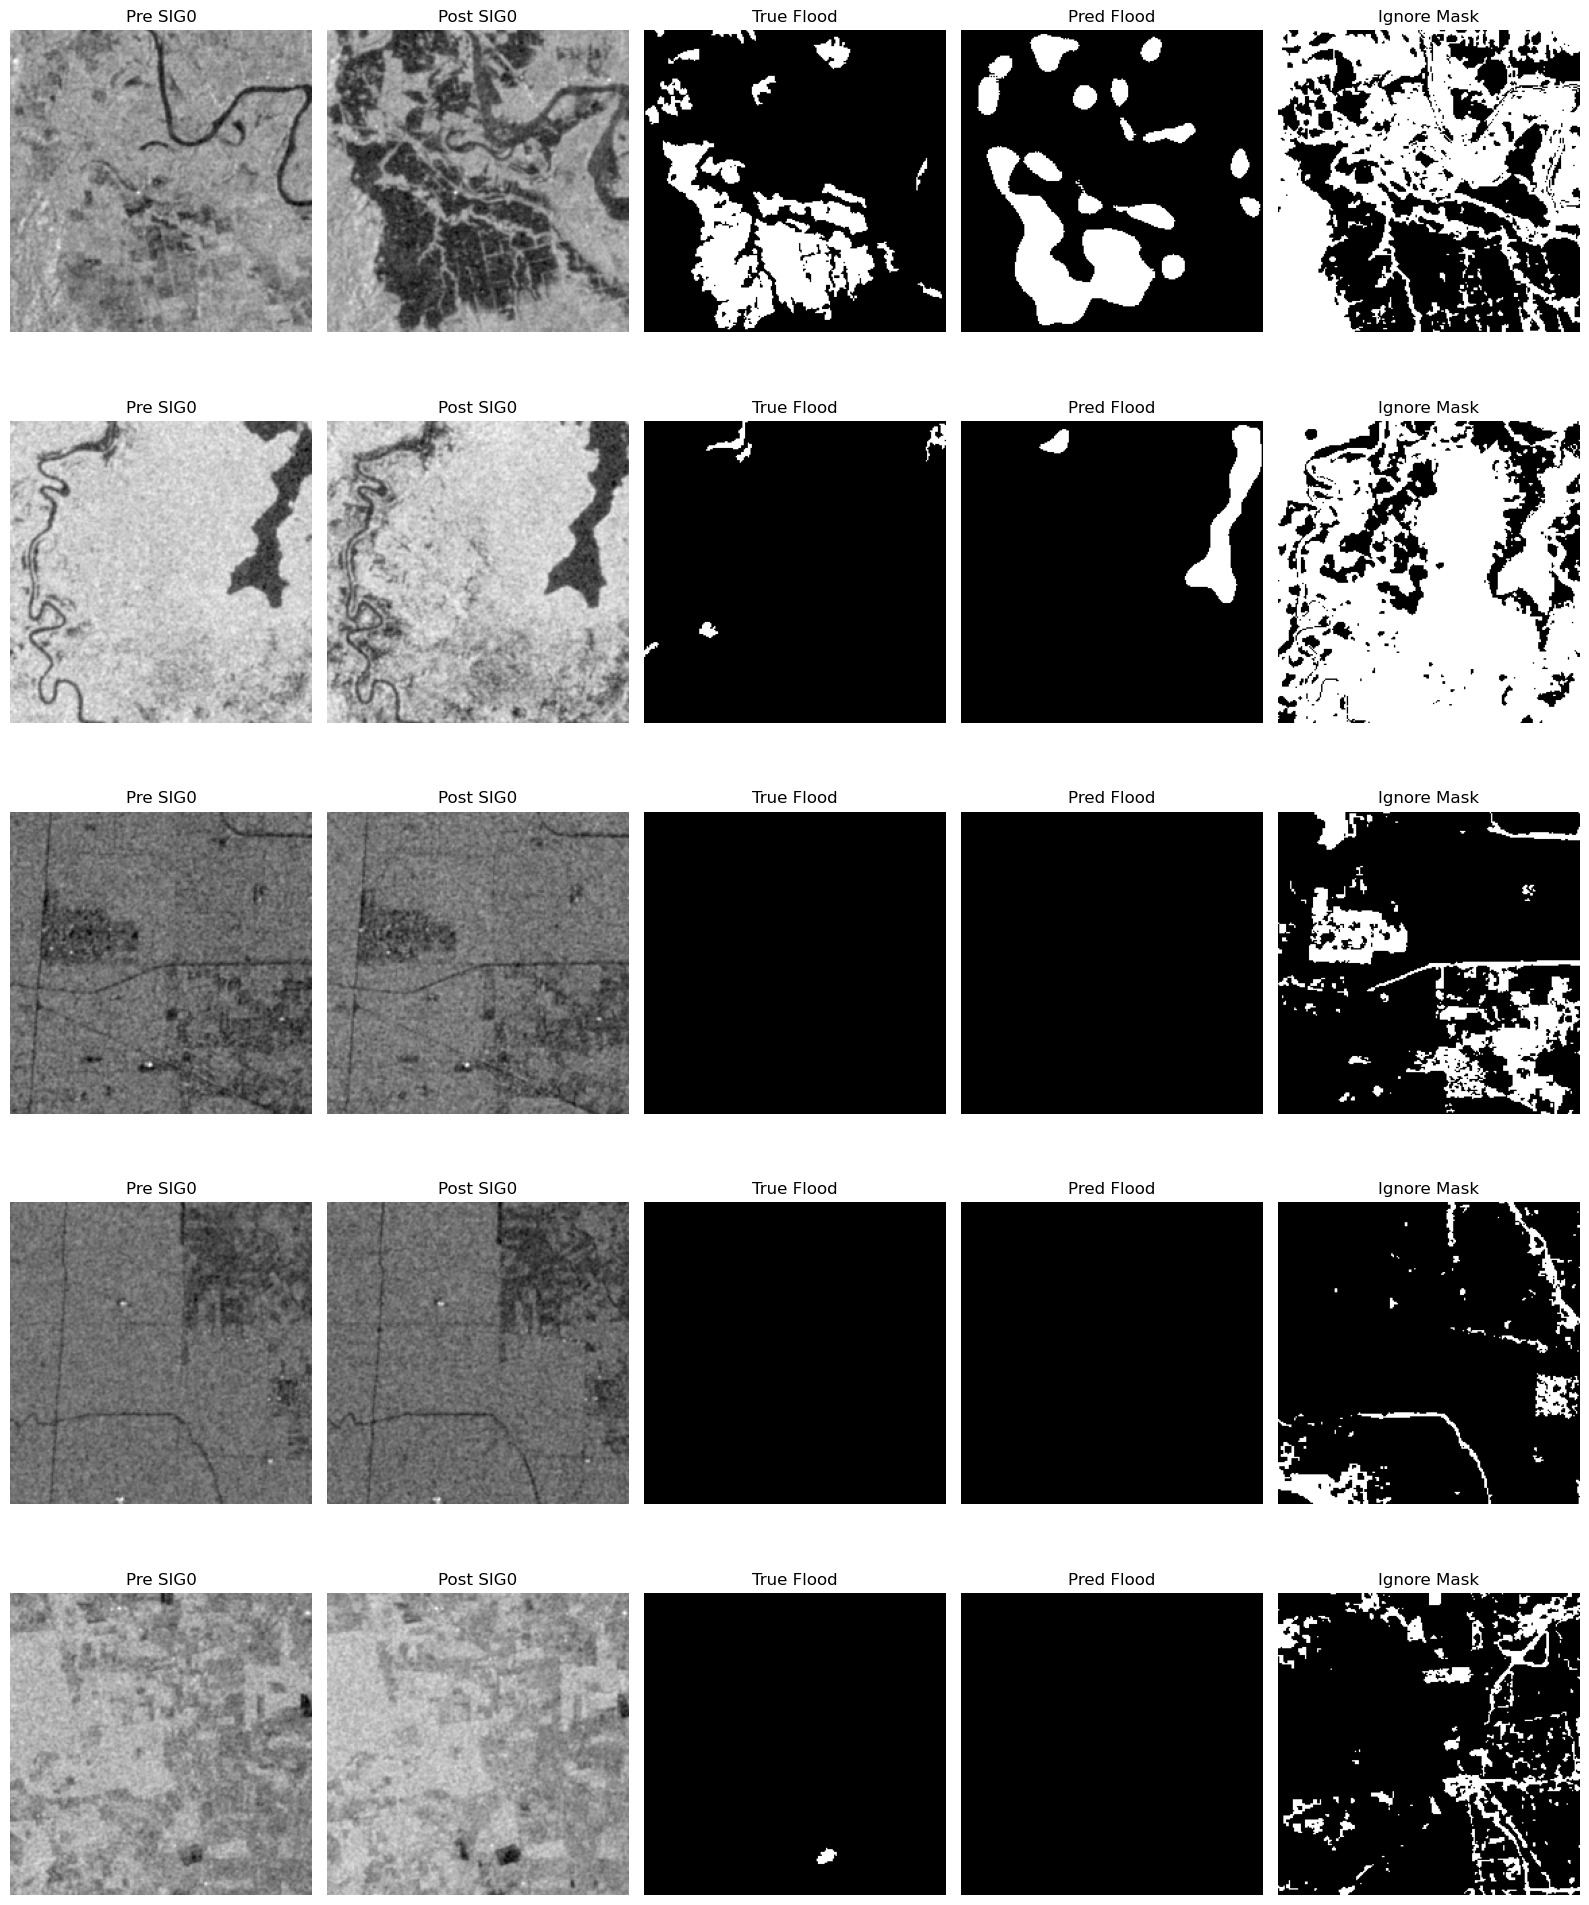

In [12]:
# Visualize random test samples
plot_random_n_chips(model, config_path_yaml=CONFIG_PATH, n=5, split="test")


In [14]:
import random
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
import rasterio as rio


def plot_random_n_chips_overlapped(model, config_path_yaml, n: int = 5, split: str = "test"):
    """
    Visualize random chips for the GFM setup using paired pre/post embeddings and binary flood labels.

    Shows: pre SIG0, post SIG0, and confusion matrix overlay where:
    - TN (True Negative): Black (K)
    - TP (True Positive): White (W)
    - FP (False Positive): Green (G)
    - FN (False Negative): Blue (B)
    - Exclusion: Red (R)
    """
    with open(config_path_yaml, "r") as f:
        config_dict = yaml.safe_load(f)

    if split == "train":
        embedding_path = Path(config_dict["data"]["train_embedd_dir"])
        labels_path = Path(config_dict["data"]["train_label_dir"])
    elif split == "val":
        embedding_path = Path(config_dict["data"]["val_embedd_dir"])
        labels_path = Path(config_dict["data"]["val_label_dir"]) 
    elif split == "test":
        embedding_path = Path(config_dict["data"]["test_embedd_dir"])
        labels_path = Path(config_dict["data"]["test_label_dir"]) 
    else:
        raise ValueError("split must be 'train', 'val' or 'test'")

    chips_path = embedding_path.parent

    # Pair pre/post embeddings by chip index
    all_embed_files = [p.name for p in embedding_path.glob("*.npy")]
    key_to_files = {}
    for fname in all_embed_files:
        key = fname.split("chip", 1)[1] if "chip" in fname else Path(fname).stem
        key_to_files.setdefault(key, []).append(fname)
    paired_items = [(k, sorted(v)) for k, v in key_to_files.items() if len(v) == 2]
    paired_items.sort(key=lambda x: x[0])

    if len(paired_items) == 0:
        raise RuntimeError(f"No paired embeddings found in {embedding_path}")

    if n > len(paired_items):
        raise ValueError(
            f"n ({n}) is greater than the number of available pairs ({len(paired_items)})"
        )

    selected = random.sample(paired_items, n)

    # Prepare predictions
    model.eval()

    # Create figure with 3 columns: Pre, Post, Overlay
    _, axs = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axs = np.expand_dims(axs, axis=0)

    # Define colormap: 0=TN(Black), 1=TP(White), 2=FP(Green), 3=FN(Blue), 4=Exclusion(Red)
    colors = ['black', 'white', 'green', 'blue', 'red']
    cmap = ListedColormap(colors)

    for row_idx, (key, pair_files) in enumerate(selected):
        pre_name, post_name = pair_files[0], pair_files[1]
        pre_path = embedding_path / pre_name
        post_path = embedding_path / post_name

        # Derive chip index
        if "chip_" not in pre_name:
            chip_idx = Path(pre_name).stem
        else:
            token = pre_name.split("chip_", 1)[1]
            for char in token:
                if char.isnumeric(): 
                    continue
                else:
                    chip_idx = token.split(char, 1)[0]
                    break

        # Load embeddings
        pre_embedding = np.load(pre_path).astype(np.float32)
        post_embedding = np.load(post_path).astype(np.float32)

        # Find and load labels/masks
        def find_first(pattern):
            matches = list((labels_path).glob(pattern))
            if len(matches) == 0:
                raise FileNotFoundError(f"No file matching {pattern} in {labels_path}")
            return matches[0]

        lbl_path = find_first(f"*FLOOD*chip_{chip_idx}*.npy")
        excl_path = find_first(f"*EXCLAYER*chip_{chip_idx}*.npy")
        water_path = find_first(f"*REFERENCE_WATER*chip_{chip_idx}*.npy")

        label = np.load(lbl_path).astype(np.uint8)
        excl = np.load(excl_path).astype(bool)
        water = (np.load(water_path) == 1)
        ignore_mask = (excl | water).astype(bool)

        # Load corresponding raw chip images
        chip_files = sorted(list((chips_path).glob(f"*chip_{chip_idx}*.tif")))
        pre_img = None
        post_img = None
        if len(chip_files) >= 2:
            with rio.open(chip_files[0]) as src:
                pre_img_np = src.read().astype(np.float32)
            with rio.open(chip_files[1]) as src:
                post_img_np = src.read().astype(np.float32)
            
            pre_img = pre_img_np[0] if pre_img_np.ndim == 3 else pre_img_np
            post_img = post_img_np[0] if post_img_np.ndim == 3 else post_img_np

        pre_img_batch = pre_img_np
        post_img_batch = post_img_np
            
        # Predict
        with torch.no_grad():
            batch = {
                "pre_embedding": torch.from_numpy(pre_embedding).unsqueeze(0),
                "post_embedding": torch.from_numpy(post_embedding).unsqueeze(0),
                "pre_image": torch.from_numpy(pre_img_batch).unsqueeze(0),
                "post_image": torch.from_numpy(post_img_batch).unsqueeze(0),
            }
            logits = model(batch)
            probs = torch.sigmoid(logits).squeeze(0).squeeze(0).cpu().numpy()
            pred_mask = (probs > 0.5).astype(np.uint8)

        # Create confusion matrix overlay
        # Initialize with TN (0 = black)
        overlay = np.zeros_like(label, dtype=np.uint8)
        
        # True Positives: label=1 AND pred=1 -> 1 (white)
        overlay[(label == 1) & (pred_mask == 1)] = 1
        
        # False Positives: label=0 AND pred=1 -> 2 (green)
        overlay[(label == 0) & (pred_mask == 1)] = 2
        
        # False Negatives: label=1 AND pred=0 -> 3 (blue)
        overlay[(label == 1) & (pred_mask == 0)] = 3
        
        # Exclusion layer overrides everything -> 4 (red)
        overlay[ignore_mask] = 4

        # Plot
        if pre_img is not None:
            axs[row_idx, 0].imshow(pre_img, cmap="gray")
            axs[row_idx, 0].set_title("Pre SIG0")
        else:
            axs[row_idx, 0].axis("off")
            axs[row_idx, 0].set_title("Pre SIG0 (n/a)")

        if post_img is not None:
            axs[row_idx, 1].imshow(post_img, cmap="gray")
            axs[row_idx, 1].set_title("Post SIG0")
        else:
            axs[row_idx, 1].axis("off")
            axs[row_idx, 1].set_title("Post SIG0 (n/a)")

        # Plot overlay with custom colormap
        im = axs[row_idx, 2].imshow(overlay, cmap=cmap, vmin=0, vmax=4)
        axs[row_idx, 2].set_title("Overlay (TN:K, TP:W, FP:G, FN:B, Excl:R)")

        for c in range(3):
            axs[row_idx, c].axis("off")

    plt.tight_layout()
    plt.show()

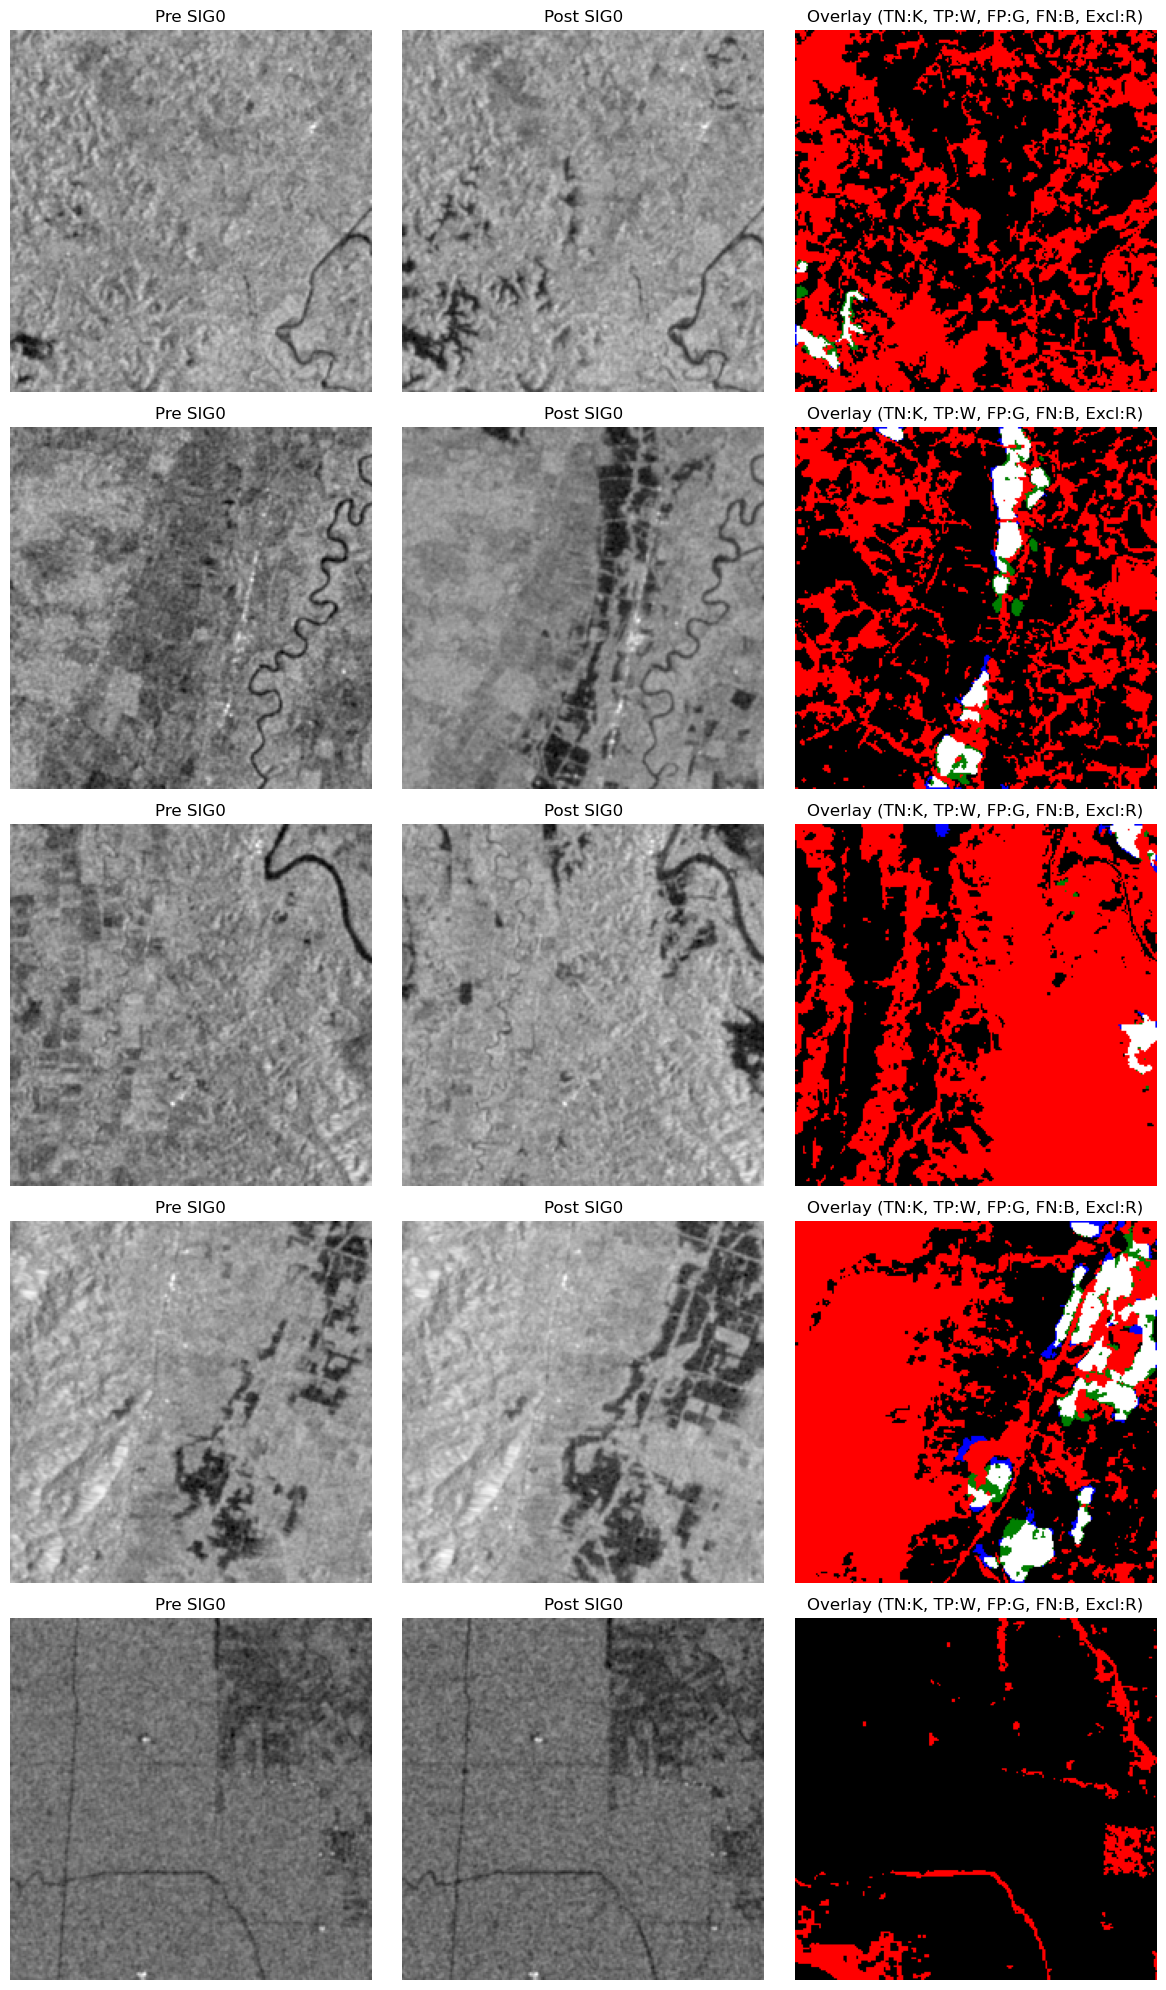

In [16]:
# Visualize random test samples
plot_random_n_chips_overlapped(model, config_path_yaml=CONFIG_PATH, n=5, split="test")
